In [1]:
from transformers import AutoTokenizer
import json
from datasets import Dataset
import numpy as np
from skmultilearn.model_selection import iterative_train_test_split

In [23]:
file_path1 = "data/sample_new_1_14.jsonl"  # Update with your actual file path
with open(file_path1, "r") as f:
    data1 = [json.loads(line) for line in f]
print (f"data len {len(data1)}")
file_path2 = "data/Bethesda1_3_message_processed.jsonl"  # Update with your actual file path
with open(file_path2, "r") as f:
    data2 = [json.loads(line) for line in f]
print (f"data len {len(data2)}")
file_path3 = "data/Woven_message_processed.jsonl"  # Update with your actual file path
with open(file_path3, "r") as f:
    data3 = [json.loads(line) for line in f]
print (f"data len {len(data3)}")
file_path4 = "data/Survey_message_processed.jsonl"  # Update with your actual file path
with open(file_path4, "r") as f:
    data4 = [json.loads(line) for line in f]
print (f"data len {len(data4)}")
file_path5 = "data/Demo_message.jsonl"  # Update with your actual file path
with open(file_path5, "r") as f:
    data5 = [json.loads(line) for line in f]
print (f"data len {len(data5)}")

data len 517
data len 165
data len 61
data len 96
data len 298


In [24]:
data1 = data1 + data2 + data3 + data4 + data5

In [25]:
len(data1)

1137

In [26]:
len(data5)

298

In [27]:
len(data1)

1137

In [28]:
data1[-1]

{'context': "Single Message: patient: | Good afternoon Dr. Person1 this is Person2 I had an appointment with you about 2 months ago regarding cist in my throat. It's been more than 3 weeks my throat is really bothering me specially from the right side and when I touch it I feel it is swollen and this one is not in the same spot this is in different spot even when i swallow anything it's hurting I wanted to see you this week if it's possible please let me know thank you.\n",
 'annotations': [{'start': 27,
   'end': 41,
   'text': 'Good afternoon',
   'codes': ['PartnershipPatient', 'salutation']},
  {'start': 72,
   'end': 95,
   'text': 'had an appointment with',
   'codes': ['PartnershipPatient', 'Clinical care']},
  {'start': 129,
   'end': 146,
   'text': 'cist in my throat',
   'codes': ['PartnershipPatient', 'Clinical care']},
  {'start': 179,
   'end': 205,
   'text': 'throat is really bothering',
   'codes': ['PartnershipPatient', 'Clinical care']},
  {'start': 209,
   'end': 23

In [29]:
len(data1)

1137

In [30]:
from transformers import AutoTokenizer
import json
from datasets import Dataset
import numpy as np
from skmultilearn.model_selection import iterative_train_test_split

# Step 1: Tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
raw_data = data1
# Unify the annotation labels
# standard_code = [
#     "InfoGive",
#     "InfoSeek",
#     "PartnershipPatient",
#     "PartnershipProvider",
#     "Socioemotional/Empathy",
#     "SharedDecisionPatient",
#     "SharedDecisionProvider"
# ]
# standard_subcode = [
#     'AcknowledgeError',
#     'Alignment',
#     'Appreciation/Gratitude',
#     'Diagnostics',
#     'Drugs',
#     'Sadness/fear',
#     'SchedulingAppt',
#     'Symptoms',
#     'carecoordination',
#     'connection',
#     'PositiveRemarks/Reward',
#     'maintainCommunication',
#     'salutation',
#     'signoff'
# ]
# standard_code = set(standard_code)
# standard_subcode = set(standard_subcode)



sizes = []
for item in raw_data:
    from_whom = "Provider" if item["meta"]["TO_PAT_YN"] == "Y" else "Patient"
    sentence = item["context"]
    input_text = f"From {from_whom}: {sentence}"
    sizes.append(len(tokenizer.tokenize(input_text)))

(array([462., 353., 167.,  95.,  31.,  16.,   6.,   4.,   1.,   2.]),
 array([  4. ,  37.2,  70.4, 103.6, 136.8, 170. , 203.2, 236.4, 269.6,
        302.8, 336. ]),
 <BarContainer object of 10 artists>)

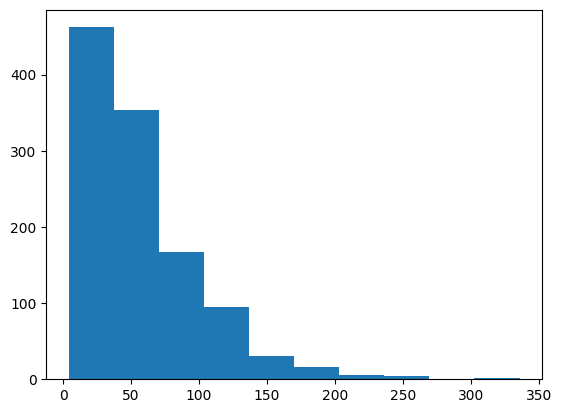

In [31]:
import matplotlib.pyplot as plt

plt.hist(sizes)

In [32]:
def my_clean(txt):
    if "|" in txt:
        txt = txt.split("|")[1]
    txt = txt.strip()
    txt = " ".join(txt.split())
    return txt
def my_clean_label(txt):
    # if txt == "socioemotionalempathy":
    #     txt = "Socioemotional/Empathy"
    # if txt.lower() == "infoseek":
    #     txt =  "InfoSeek"
    # if txt.lower() == "infogive":
    #     txt =  "InfoGive"
    # if txt.lower() == "saddness/fear":
    #     txt =  "Sadness/fear"
    # if txt == "PositiveRemarks":
    #     txt =  "PositiveRemarks/Reward"
    # if txt.lower() == "symptoms":
    #     txt =  "Symptoms"
    # if txt.lower() == "expressconcern,unease" or txt.lower() == "expressconcern/unease":
    #     txt =  "expressconcern/unease"
    # if txt.lower() == "expressconcern,unease":
    #     txt =  "expressconcern/unease"
    # if txt.lower() == "instruction":
    #     txt =  "Instruction"
    # if txt == 'Requests for Opinion' or txt == 'acknowledgePatientExpertiseKnowledge' or txt == 'EncourageQuestions':
    #     return None
    # if txt not in standard_code and txt not in standard_subcode:
    #     return None
    if txt == "SocioEmotionalEmpathy":
        txt = "SocioEmotionalBehaviour"
    return txt
print (f"total number of data {len(raw_data)}")
all_labels = set()
processed = []
count_later = 0
for item in raw_data:
    from_whom = "Provider" if item["meta"]["TO_PAT_YN"] == "Y" else "Patient"
    sentence = my_clean(item["context"])
    if "|" in sentence:
        count_later += 1
        print (sentence)
    input_text = f"From {from_whom}: {sentence}"
    label_list = []
    for ann in item.get("annotations"):
        if len(ann['codes']) >= 2:
            code_main = my_clean_label(ann['codes'][0])
            code_sub = my_clean_label(ann['codes'][1])
        elif len(ann['codes']) == 1:
            code_main = my_clean_label(ann['codes'][0])
            code_sub = 'None'
        else:
            continue
        # if code_main == "SharedDecisionPatient" or code_main == "SharedDecisionProvider":
        #     code_sub = "None"
        # if code_main is None or code_sub is None:
        #     continue
        label_list.append(f"{code_main}_{code_sub}")
    if (len(label_list) == 0):
        continue
    all_labels.update(label_list)
    processed.append({"text": input_text, "labels": label_list, "messageID": item["meta"]["MESSAGE_ID"]})
print ("count later is ", count_later)
processed[1]

total number of data 1137
count later is  0


{'text': "From Patient: Dr.Person1 I need my prescription sent to the pharmacy for my flecainide acetate 100 mg tablets twice a day the pharmacist has try requesting it no success and I don't have any pills. Person2",
 'labels': ['PartnershipPatient_activeParticipation/involvement',
  'SDOH_HealthCareAccessAndQuality',
  'PartnershipPatient_Clinical care',
  'PartnershipPatient_Clinical care',
  'CareCoordinationPatient_None',
  'SDOH_NeighborhoodAndBuiltEnvironment'],
 'messageID': 75988585}

In [33]:


# Step 3: Label Mapping
all_labels = sorted(list(all_labels))
label2id = {label: idx for idx, label in enumerate(all_labels)}
id2label = {idx: label for label, idx in label2id.items()}

# Step 4: Convert labels to binary matrix
def get_label_vector(label_list):
    vec = [0] * len(label2id)
    for label in label_list:
        vec[label2id[label]] = 1
    return vec

X = np.array([entry["text"] for entry in processed]).reshape(-1, 1)
Y = np.array([get_label_vector(entry["labels"]) for entry in processed])
#X = np.array([f"{entry["text"]}|{entry["messageID"]}" for entry in processed]).reshape(-1, 1)
#Z = np.array([get_label_vector(entry["messageID"]) for entry in processed])

# Step 5: Stratified Split
X_train, Y_train, X_test, Y_test = iterative_train_test_split(X, Y, test_size=0.2)

# Step 6: Reconstruct HF dataset structure
train_data = [{"text": x[0], "labels": [all_labels[i] for i, v in enumerate(y) if v == 1]} for x, y in zip(X_train, Y_train)]
test_data  = [{"text": x[0], "labels": [all_labels[i] for i, v in enumerate(y) if v == 1]} for x, y in zip(X_test, Y_test)]

In [34]:
from collections import Counter

def count_labels(dataset):
    counter = Counter()
    for sample in dataset:
        counter.update(sample["labels"])
    return counter

train_counts = count_labels(train_data)
test_counts = count_labels(test_data)

# Display counts side-by-side
print("Label\t Train\t Test")
for label in all_labels:
    print(f"{label}\t | {train_counts[label]}\t | {test_counts[label]}")

Label	 Train	 Test
CareCoordinationPatient_None	 | 143	 | 39
CareCoordinationProvider_None	 | 127	 | 35
PartnershipPatient_Appreciation/Gratitude	 | 104	 | 26
PartnershipPatient_Clinical care	 | 386	 | 101
PartnershipPatient_None	 | 2	 | 0
PartnershipPatient_activeParticipation/involvement	 | 362	 | 91
PartnershipPatient_alignment	 | 37	 | 12
PartnershipPatient_build trust	 | 19	 | 4
PartnershipPatient_connection	 | 47	 | 14
PartnershipPatient_expressOpinions	 | 139	 | 38
PartnershipPatient_salutation	 | 208	 | 52
PartnershipPatient_signoff	 | 205	 | 51
PartnershipPatient_statePreferences	 | 59	 | 15
PartnershipProvider_Appreciation/Gratitude	 | 18	 | 5
PartnershipProvider_Clinical Care	 | 201	 | 56
PartnershipProvider_acknowledgePatientExpertiseKnowledge	 | 1	 | 0
PartnershipProvider_alignment	 | 40	 | 12
PartnershipProvider_build trust	 | 10	 | 4
PartnershipProvider_checkingUnderstanding/clarification	 | 47	 | 14
PartnershipProvider_connection	 | 48	 | 12
PartnershipProvider_inviteCo

In [35]:
import json

with open("data/stratified_train_data_pinfo.json", "w") as f:
    json.dump(train_data, f, indent=4)

with open("data/stratified_test_data_pinfo.json", "w") as f:
    json.dump(test_data, f, indent=4)

In [13]:
len(train_data)

645

In [14]:
len(test_data)

192